<a href="https://colab.research.google.com/github/IlhamFaturachman/pcvk-ganjil-2025/blob/main/week5_pcvk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCVK – Modul 5: Gamma Correction, Bit Depth, PSNR/Average Denoising, Image Masking

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import yang diperlukan
import os, glob, math, sys
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

print('OpenCV version:', cv.__version__)

OpenCV version: 4.12.0


## Utilitas umum

In [3]:
def imread_gray(path):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"[PERINGATAN] Gagal membaca: {path}. Membuat contoh sintetis 256×256.")
        x = np.linspace(0, 1, 256)
        y = np.linspace(0, 1, 256)
        X, Y = np.meshgrid(x, y)
        img = (255*(0.5*X + 0.5*Y)).astype(np.uint8)
    return img

def imread_color(path):
    img = cv.imread(path, cv.IMREAD_COLOR)
    if img is None:
        print(f"[PERINGATAN] Gagal membaca: {path}. Membuat contoh sintetis warna 256×256.")
        H, W = 256, 256
        x = np.linspace(0, 1, W)
        y = np.linspace(0, 1, H)
        X, Y = np.meshgrid(x, y)
        r = (255*X).astype(np.uint8)
        g = (255*Y).astype(np.uint8)
        b = (255*(1-X)).astype(np.uint8)
        img = cv.merge([b, g, r])
    return img

def show(title, img, cmap=None):
    plt.figure()
    if len(img.shape)==2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100.0
    PIXEL_MAX = 255.0
    return 20 * math.log10(PIXEL_MAX / math.sqrt(mse))

## 1) Gamma Correction (dengan input pengguna)
Rumus (modul, *gamma correction* memakai eksponen $1/\gamma$):
$$I' = 255 \cdot (I/255)^{1/\gamma}$$

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


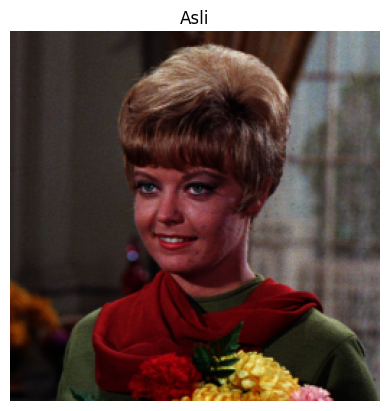

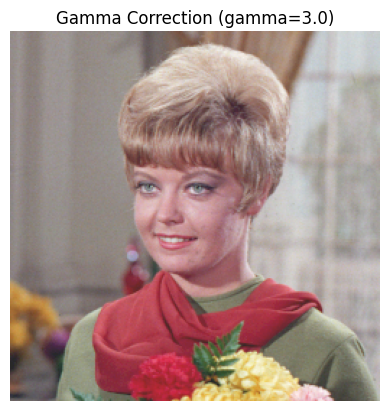

In [8]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except Exception:
    print('Error, not a number. Pakai default gamma=3.0')
    gamma = 3.0

img_path = '/content/drive/MyDrive/PCVK/female.tiff'
img = imread_color(img_path)

gamma_corrected = ((img/255.0) ** (1.0/max(gamma, 1e-8)))
gamma_corrected = np.clip(255*gamma_corrected, 0, 255).astype(np.uint8)

show('Asli', img)
show(f'Gamma Correction (gamma={gamma})', gamma_corrected)

## 2) Simulasi Image Depth (Bit Depth 1–7 bit)
Rumus dari modul:

$$\text{level} = \frac{255}{2^{bit\_depth}-1}, \quad C' = \operatorname{round}\Big((C/\text{level})\cdot \text{level}\Big)$$

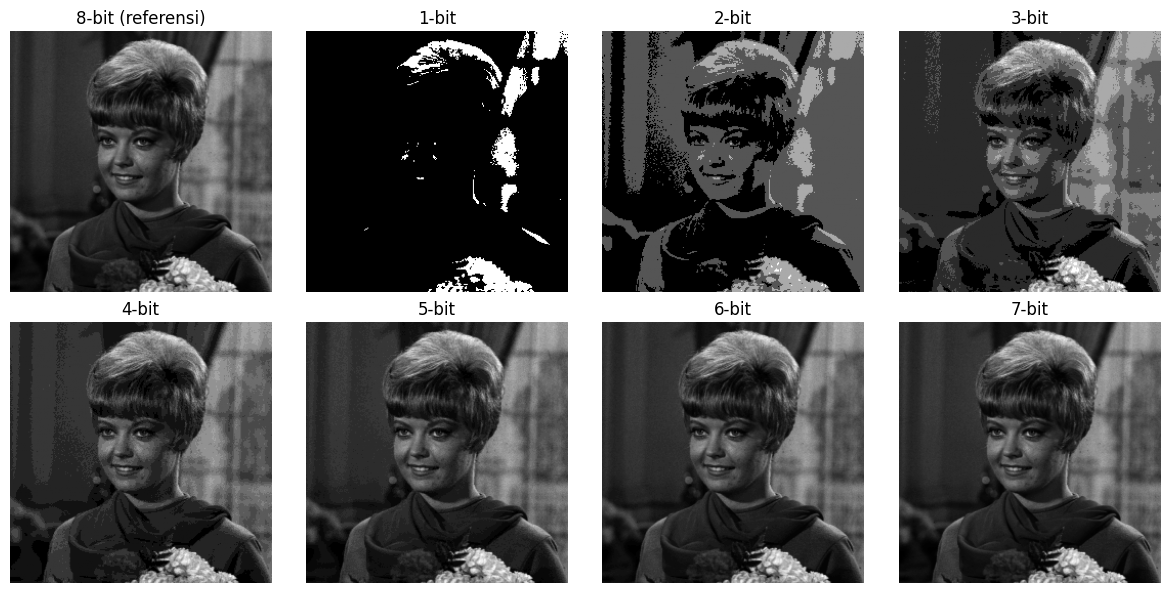

In [9]:
gray = cv.cvtColor(imread_color('/content/drive/MyDrive/PCVK/female.tiff'), cv.COLOR_BGR2GRAY)

def quantize_bit_depth(gray, bit_depth):
    bit_depth = int(bit_depth)
    levels = (2**bit_depth) - 1
    level = 255.0 / levels
    out = np.round((gray/level))*level
    return np.clip(out, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.ravel()
axes[0].imshow(gray, cmap='gray'); axes[0].set_title('8-bit (referensi)'); axes[0].axis('off')
for i, bd in enumerate(range(1,8), start=1):
    q = quantize_bit_depth(gray, bd)
    axes[i].imshow(q, cmap='gray'); axes[i].set_title(f'{bd}-bit'); axes[i].axis('off')
plt.tight_layout(); plt.show()

## 3) Average Denoising + PSNR
Kita merata-ratakan $N$ citra ber-noise untuk menekan noise acak. Hitung PSNR hasil rata-rata terhadap citra asli.

Ditemukan 100 citra noise.


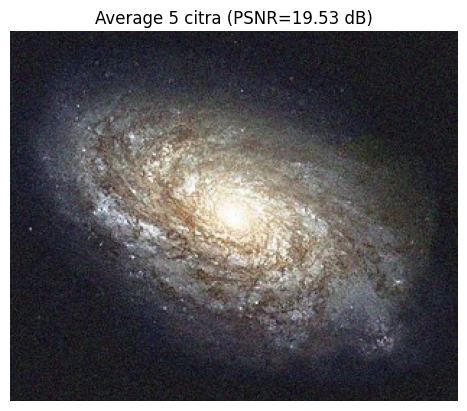

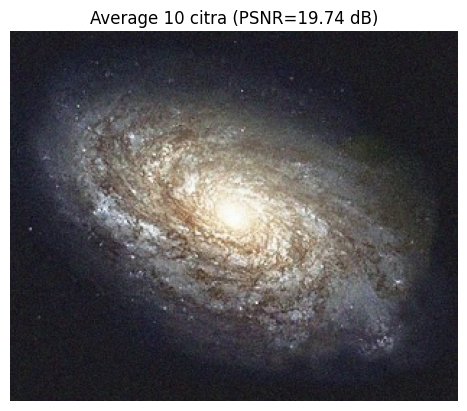

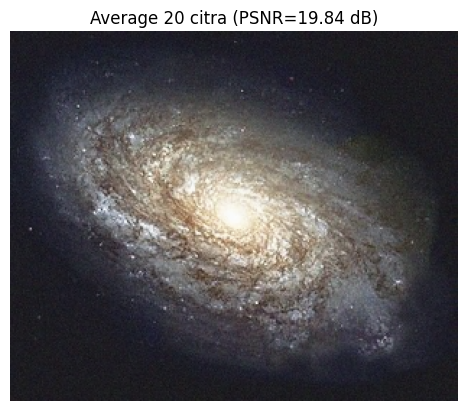

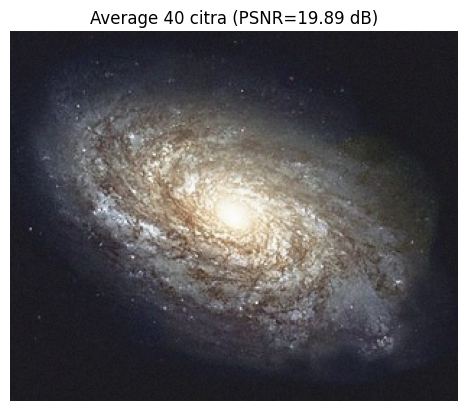

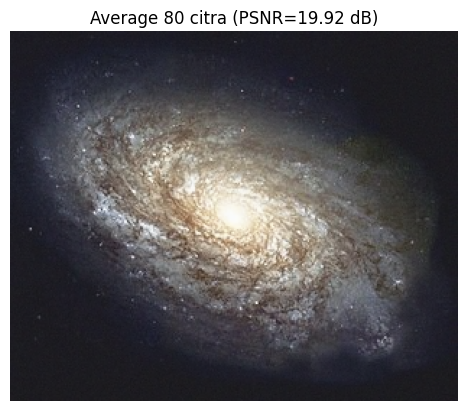

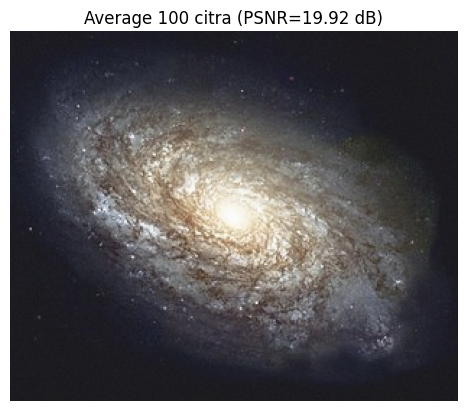


Ringkasan PSNR:
- N=5: PSNR=19.53 dB
- N=10: PSNR=19.74 dB
- N=20: PSNR=19.84 dB
- N=40: PSNR=19.89 dB
- N=80: PSNR=19.92 dB
- N=100: PSNR=19.92 dB


In [10]:
orig_path = '/content/drive/MyDrive/PCVK/galaxy.jpg'
noises_glob = '/content/drive/MyDrive/PCVK/noises/*.jpg'

orig = imread_color(orig_path)
noise_list = []
for p in sorted(glob.glob(noises_glob)):
    img = imread_color(p)
    if img.shape != orig.shape:
        img = cv.resize(img, (orig.shape[1], orig.shape[0]))
    noise_list.append(img)

print(f"Ditemukan {len(noise_list)} citra noise.")

def average_denoise(imgs):
    acc = np.zeros_like(imgs[0], dtype=np.float64)
    for im in imgs:
        acc += im.astype(np.float64)
    avg = (acc / len(imgs))
    return np.clip(avg, 0, 255).astype(np.uint8)

counts = [5, 10, 20, 40, 80, 100]
results = []
for n in counts:
    if len(noise_list) >= n and len(noise_list)>0:
        den = average_denoise(noise_list[:n])
        psnr = PSNR(orig, den)
        results.append((n, den, psnr))
        show(f'Average {n} citra (PSNR={psnr:.2f} dB)', den)
    else:
        print(f"[INFO] Tidak cukup citra noise untuk n={n}. Melewati perhitungan ini.")

print('\nRingkasan PSNR:')
for n, _, ps in results:
    print(f"- N={n}: PSNR={ps:.2f} dB")

In [11]:
if results:
    # tren sederhana: apakah PSNR meningkat terhadap N?
    inc = all(results[i][2] >= results[i-1][2] for i in range(1, len(results)))
    trend = 'meningkat seiring bertambahnya jumlah citra' if inc else 'tidak monoton meningkat (periksa data/noise)'
    print('• Secara umum, PSNR', trend, '. Semakin banyak citra yang dirata-rata, noise acak makin tereduksi dan kualitas meningkat (diminishing returns).')
else:
    print('• Data noise tidak tersedia, sehingga kesimpulan numerik tidak dapat dihitung di lingkungan ini.')

• Secara umum, PSNR meningkat seiring bertambahnya jumlah citra . Semakin banyak citra yang dirata-rata, noise acak makin tereduksi dan kualitas meningkat (diminishing returns).


## 4) Image Masking (AND) + Eksperimen Operator Logika Lain (NOT, OR, AND, NAND, XOR)

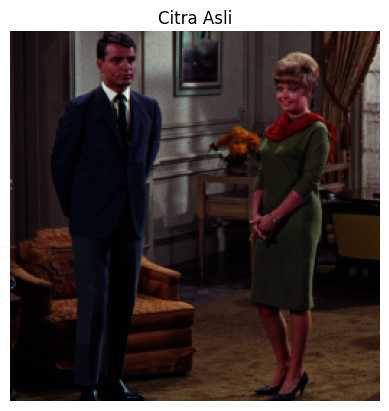

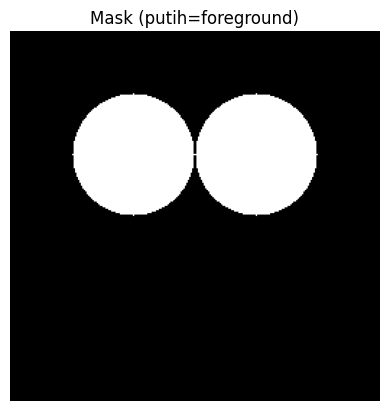

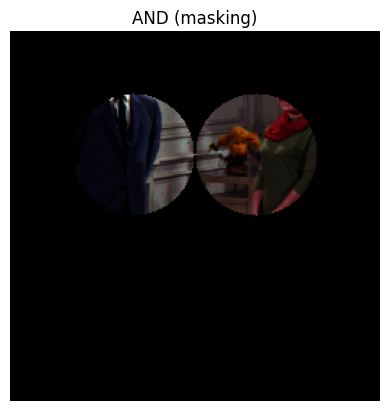

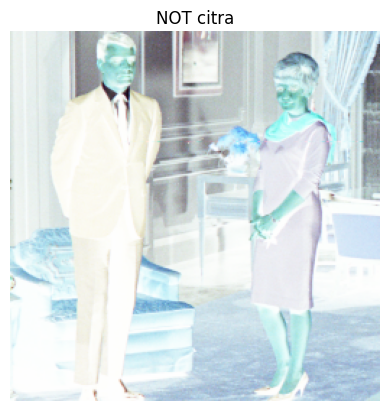

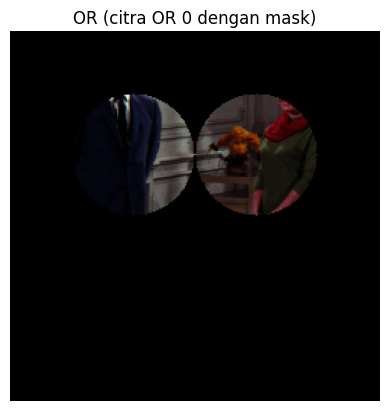

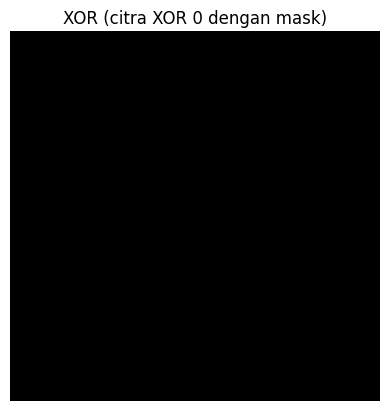

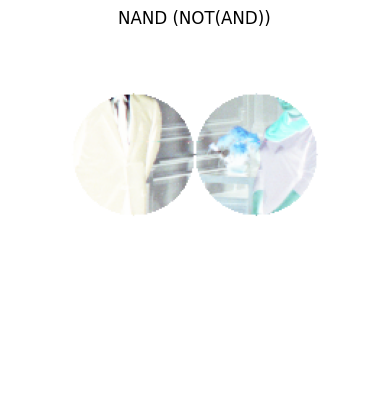

In [14]:
src = imread_color('/content/drive/MyDrive/PCVK/couples.tiff')
H, W = src.shape[:2]

# Buat dua masker lingkaran
mask = np.zeros((H, W), dtype=np.uint8)
cv.circle(mask, (W//3, H//3), min(H,W)//6, 255, -1)
cv.circle(mask, (2*W//3, H//3), min(H,W)//6, 255, -1)

and_out = cv.bitwise_and(src, src, mask=mask)
not_mask = cv.bitwise_not(mask)
not_out = cv.bitwise_not(src)
or_out  = cv.bitwise_or(src, src, mask=mask)  # set area mask; di luar tetap 0
xor_out = cv.bitwise_xor(src, src, mask=mask) # sama seperti OR dengan self: set area mask
nand_out = cv.bitwise_not(and_out)

show('Citra Asli', src)
show('Mask (putih=foreground)', mask)
show('AND (masking)', and_out)
show('NOT citra', not_out)
show('OR (citra OR 0 dengan mask)', or_out)
show('XOR (citra XOR 0 dengan mask)', xor_out)
show('NAND (NOT(AND))', nand_out)

### Analisa singkat
- **NOT**: Membalik tiap bit piksel → daerah terang menjadi gelap dan sebaliknya.
- **OR** dengan mask: area *mask* (putih) mengambil piksel dari citra; area hitam tetap 0.
- **AND** dengan mask: menyimpan piksel hanya pada area *mask*, sisanya jadi 0 (hitam). Inilah *image masking* utama.
- **NAND**: kebalikan dari AND; area yang tadinya tampak menjadi ter-invers.
- **XOR** dengan mask: efeknya mirip menyalakan area *mask* di atas nol (jika operand kedua nol) → hasil sama dengan OR pada contoh ini.